Step 1:  Mount Google Drive in Colab

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Step 2:  Adding the File Path from my Google drive

In [2]:
import os

# Search for your file
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if 'marketing' in file.lower():
            print(os.path.join(root, file))

/content/drive/MyDrive/marketing_data.csv
/content/drive/MyDrive/Colab Notebooks/marketing_campaign_dataset.csv.zip
/content/drive/MyDrive/Colab Notebooks/Marketing Campaign.ipynb


Step 3: Unzip the File

In [3]:
import zipfile

zip_path = '/content/drive/MyDrive/Colab Notebooks/marketing_campaign_dataset.csv.zip'  # Corrected path

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall('/content/marketing_data/')   # extracts to Colab session

print("Files extracted:", os.listdir('/content/marketing_data/'))

Files extracted: ['marketing_campaign_dataset.csv']


Step 4: Import Libraries & Load Data

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/marketing_data/marketing_campaign_dataset.csv')
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05


Step 5: Initial Data Exploration

In [5]:
# Shape and basic info
print(df.shape)
print(df.info())
print(df.describe())

# Check for missing values
df.isnull().sum()

(200000, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       200000 non-null  int64  
 1   Company           200000 non-null  object 
 2   Campaign_Type     200000 non-null  object 
 3   Target_Audience   200000 non-null  object 
 4   Duration          200000 non-null  object 
 5   Channel_Used      200000 non-null  object 
 6   Conversion_Rate   200000 non-null  float64
 7   Acquisition_Cost  200000 non-null  object 
 8   ROI               200000 non-null  float64
 9   Location          200000 non-null  object 
 10  Language          200000 non-null  object 
 11  Clicks            200000 non-null  int64  
 12  Impressions       200000 non-null  int64  
 13  Engagement_Score  200000 non-null  int64  
 14  Customer_Segment  200000 non-null  object 
 15  Date              200000 non-null  object 
dtypes: floa

,0
Campaign_ID,0
Company,0
Campaign_Type,0
Target_Audience,0
Duration,0
Channel_Used,0
Conversion_Rate,0
Acquisition_Cost,0
ROI,0
Location,0


A. Splitting the Target Audience Column to break it into Gender and Age bucket

In [6]:
# Check unique values first
print(df['Target_Audience'].unique())
print(f"\nTotal unique combinations: {df['Target_Audience'].nunique()}")

['Men 18-24' 'Women 35-44' 'Men 25-34' 'All Ages' 'Women 25-34']

Total unique combinations: 5


B. Split into Gender and Age_Bucket

In [7]:
# Extract Gender: looks for 'Men', 'Women', or 'All' at the start
df['Gender'] = df['Target_Audience'].str.extract(r'^(Men|Women|All)')

# Extract Age Bucket: looks for a number range (e.g. 18-24) or 'All Ages'
df['Age_Bucket'] = df['Target_Audience'].str.extract(r'(\d+-\d+|All Ages)')

# Replace 'All' with a clearer label for Gender
df['Gender'] = df['Gender'].replace('All', 'All Genders')

# Fill any remaining nulls in Age_Bucket for 'All Ages' rows
df['Age_Bucket'] = df['Age_Bucket'].fillna('All Ages')

# -------------------------------------------------------------
# Verify the split AFTER transformation
# -------------------------------------------------------------
print("\nSample of Target_Audience split AFTER transformation:")
print(df[['Target_Audience', 'Gender', 'Age_Bucket']].drop_duplicates().sort_values('Target_Audience').to_string(index=False))

print("\nGender Distribution:")
print(df['Gender'].value_counts())

print("\nAge Bucket Distribution:")
print(df['Age_Bucket'].value_counts().sort_index())



Sample of Target_Audience split AFTER transformation:
Target_Audience      Gender Age_Bucket
       All Ages All Genders   All Ages
      Men 18-24         Men      18-24
      Men 25-34         Men      25-34
    Women 25-34       Women      25-34
    Women 35-44       Women      35-44

Gender Distribution:
Gender
Men            80281
Women          79700
All Genders    40019
Name: count, dtype: int64

Age Bucket Distribution:
Age_Bucket
18-24       40258
25-34       80036
35-44       39687
All Ages    40019
Name: count, dtype: int64


C. Performing the quick sanity check to see if the Total rows are still the same 200,000 and making sure everything is consistent after splitting the columns.

In [8]:
print(f"Total rows: {len(df)}")
print("\nNulls in new columns:")
print(df[['Gender', 'Age_Bucket']].isnull().sum())
# SANITY CHECK 3: No orphan combinations
# (e.g., 'All Genders' should always pair with 'All Ages')
# -------------------------------------------------------------
print("\nGender vs Age_Bucket crosstab:")
print(pd.crosstab(df['Gender'], df['Age_Bucket']))

Total rows: 200000

Nulls in new columns:
Gender        0
Age_Bucket    0
dtype: int64

Gender vs Age_Bucket crosstab:
Age_Bucket   18-24  25-34  35-44  All Ages
Gender                                    
All Genders      0      0      0     40019
Men          40258  40023      0         0
Women            0  40013  39687         0


Before doing EDA we will do some remaining data transformations like extracting numeric days from "Duration" column and extracting day, month and year from "Date" column for the time series analysis.

In [9]:
# Extract numeric days from Duration (e.g., "30 days" → 30)
df['Duration_Days'] = df['Duration'].str.extract(r'(\d+)').astype(int)

# Convert 'Date' column to datetime type
df['Date'] = pd.to_datetime(df['Date'])

# Extract Month and Year from Date for time series analysis
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['Month_Year'] = df['Date'].dt.to_period('M')

# Clean and convert 'Acquisition_Cost' to numeric
df['Acquisition_Cost'] = df['Acquisition_Cost'].replace({r'\$': '', r',': ''}, regex=True).astype(float)

print(df[['Date', 'Duration', 'Duration_Days', 'Month', 'Year', 'Month_Year', 'Acquisition_Cost']].head())

        Date Duration  Duration_Days  Month  Year Month_Year  Acquisition_Cost
0 2021-01-01  30 days             30      1  2021    2021-01           16174.0
1 2021-01-02  60 days             60      1  2021    2021-01           11566.0
2 2021-01-03  30 days             30      1  2021    2021-01           10200.0
3 2021-01-04  60 days             60      1  2021    2021-01           12724.0
4 2021-01-05  15 days             15      1  2021    2021-01           16452.0


In [10]:
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Total months covered: {df['Month_Year'].nunique()}")
print(f"Years covered: {df['Year'].unique()}")

Date range: 2021-01-01 00:00:00 to 2021-12-31 00:00:00
Total months covered: 12
Years covered: [2021]


In [11]:
print(f"Final shape: {df.shape}")
print(f"\nColumn list:\n{df.columns.tolist()}")

Final shape: (200000, 22)

Column list:
['Campaign_ID', 'Company', 'Campaign_Type', 'Target_Audience', 'Duration', 'Channel_Used', 'Conversion_Rate', 'Acquisition_Cost', 'ROI', 'Location', 'Language', 'Clicks', 'Impressions', 'Engagement_Score', 'Customer_Segment', 'Date', 'Gender', 'Age_Bucket', 'Duration_Days', 'Month', 'Year', 'Month_Year']


# Phase 1: Exploratory Data Analysis (EDA)

## A. Start with Univariate Analysis which means looking at each column individually.

In [12]:
# =============================================================
# PHASE 1 — UNIVARIATE ANALYSIS
# =============================================================
# Goal: Understand the distribution of each column individually
# We look at:
#   - Numeric columns: shape, spread, skewness
#   - Categorical columns: how many of each category exists

import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------------
# 1A. Summary Statistics for Numeric Columns
# -------------------------------------------------------------
# This gives us a quick overview of the range, mean, and spread
print("Summary Statistics for Key Numeric Columns:")
print(df[['ROI', 'Conversion_Rate', 'Acquisition_Cost',
          'Clicks', 'Impressions', 'Engagement_Score']].describe().round(2))

Summary Statistics for Key Numeric Columns:
             ROI  Conversion_Rate  Acquisition_Cost     Clicks  Impressions  \
count  200000.00        200000.00         200000.00  200000.00    200000.00   
mean        5.00             0.08          12504.39     549.77      5507.30   
std         1.73             0.04           4337.66     260.02      2596.86   
min         2.00             0.01           5000.00     100.00      1000.00   
25%         3.50             0.05           8739.75     325.00      3266.00   
50%         5.01             0.08          12496.50     550.00      5517.50   
75%         6.51             0.12          16264.00     775.00      7753.00   
max         8.00             0.15          20000.00    1000.00     10000.00   

       Engagement_Score  
count         200000.00  
mean               5.49  
std                2.87  
min                1.00  
25%                3.00  
50%                5.00  
75%                8.00  
max               10.00  


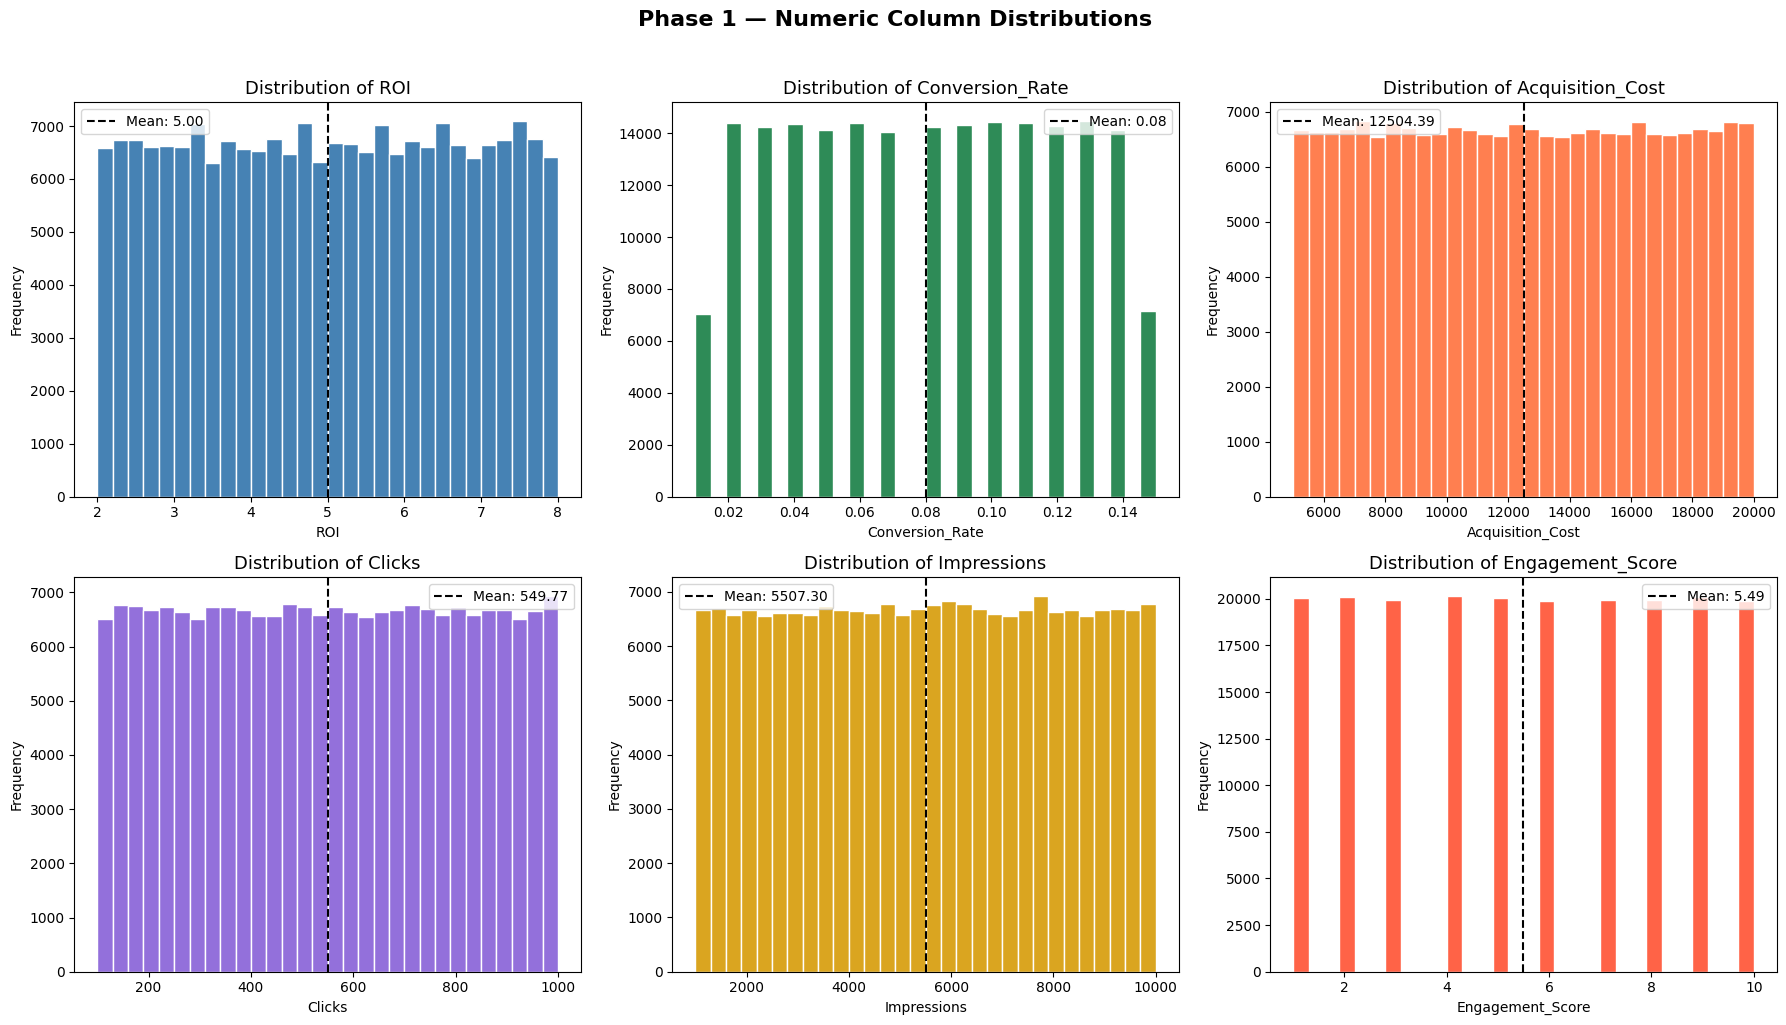

In [13]:
# -------------------------------------------------------------
# 1B. Distribution Plots for Numeric Columns
# -------------------------------------------------------------
# Histograms show us if data is normally distributed, skewed,or has any unusual patterns

numeric_cols = ['ROI', 'Conversion_Rate', 'Acquisition_Cost',
                'Clicks', 'Impressions', 'Engagement_Score']
colors = ['steelblue', 'seagreen', 'coral', 'mediumpurple', 'goldenrod', 'tomato']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col, color in zip(axes.flatten(), numeric_cols, colors):
    ax.hist(df[col], bins=30, color=color, edgecolor='white')
    ax.set_title(f'Distribution of {col}', fontsize=13)
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean: {df[col].mean():.2f}')
    ax.legend()

plt.suptitle('Phase 1 — Numeric Column Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

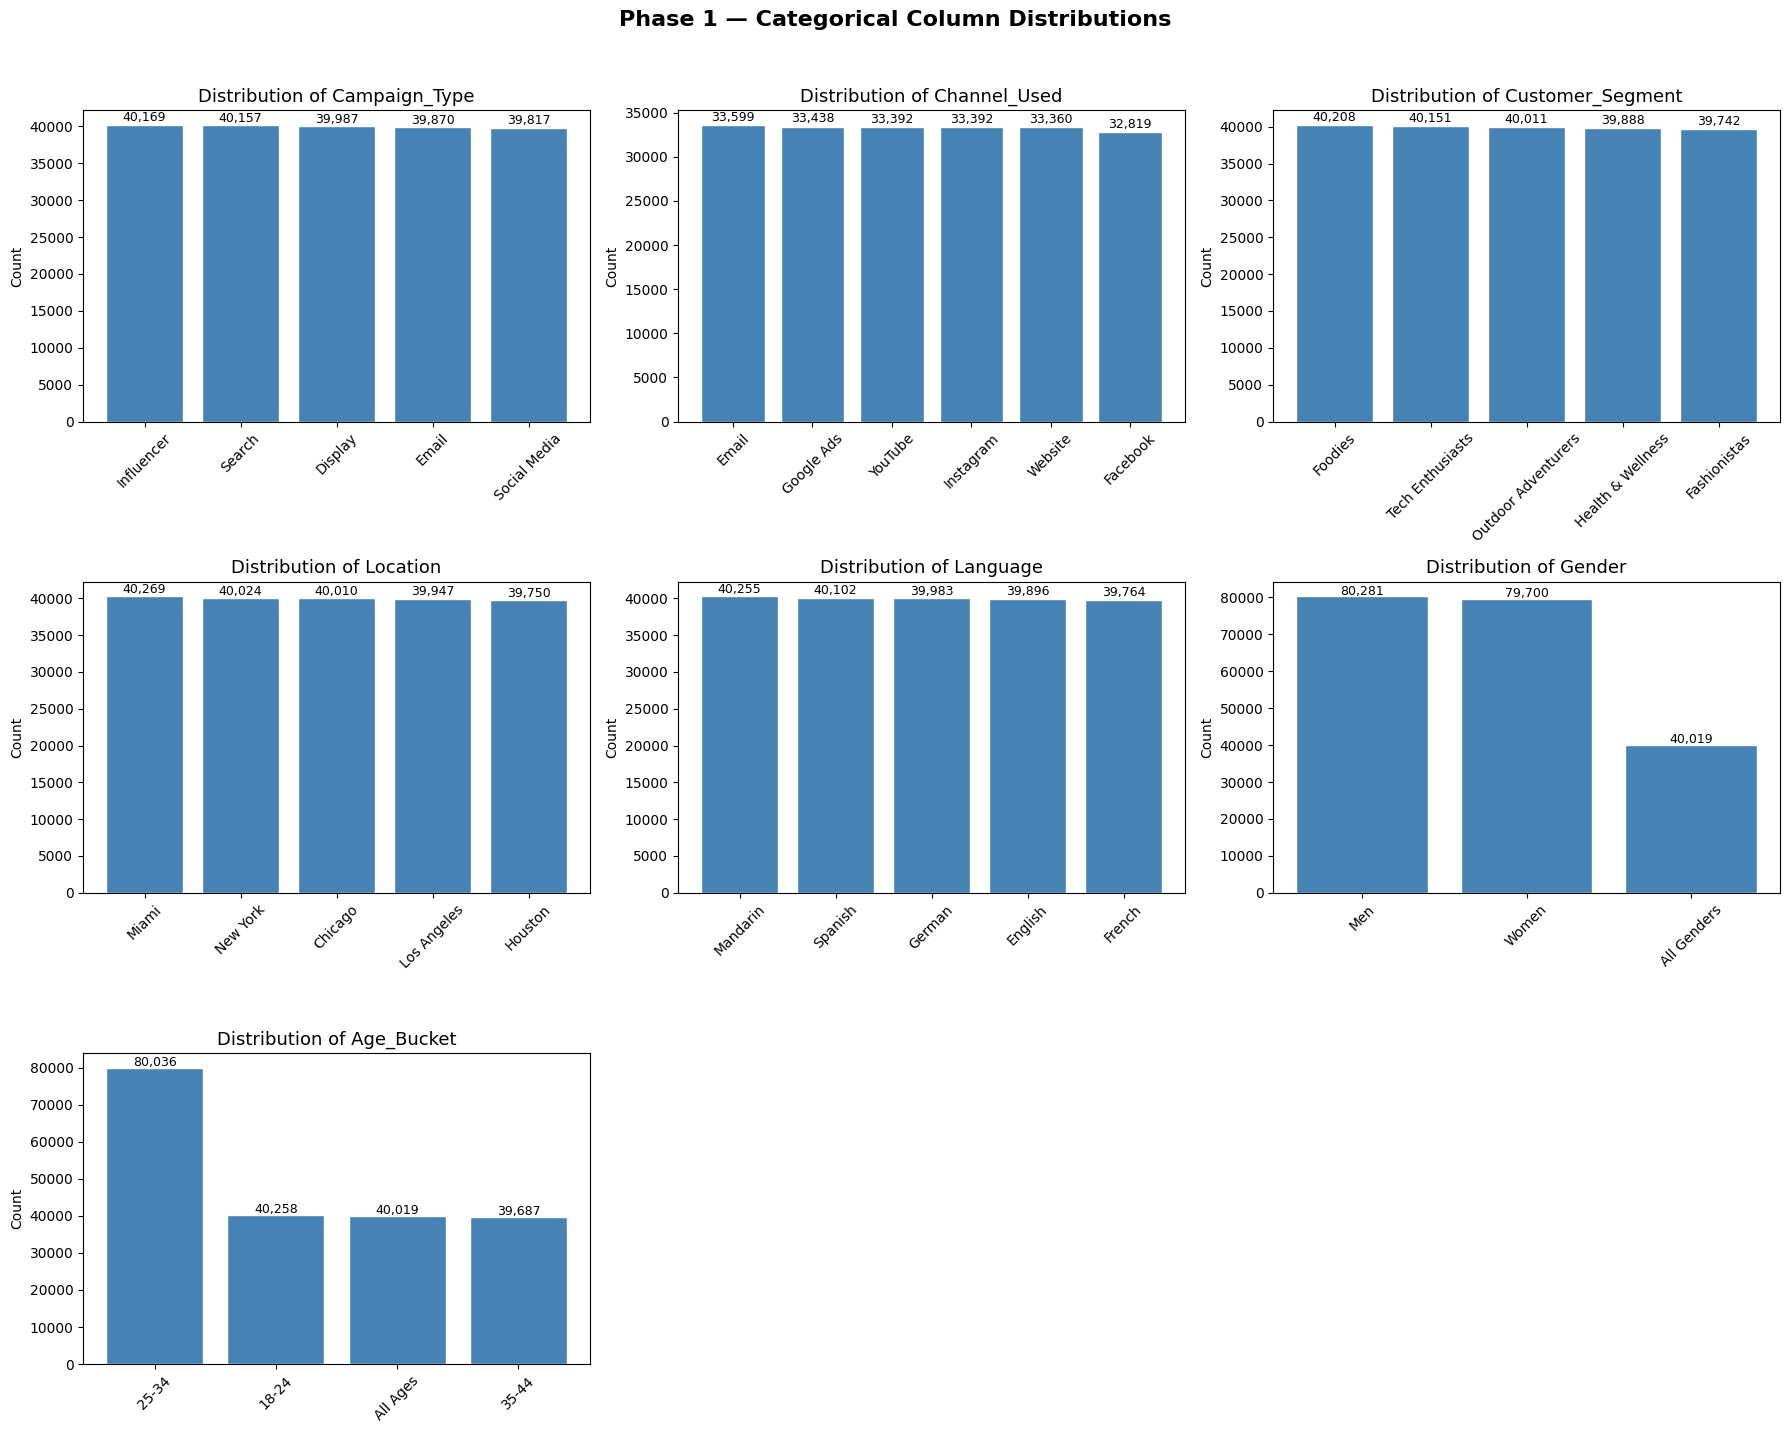

In [14]:
# -------------------------------------------------------------
# 1C. Categorical Columns — Value Counts
# -------------------------------------------------------------
# Bar charts show us how evenly spread the categories are
# Imbalanced categories can affect our analysis later

cat_cols = ['Campaign_Type', 'Channel_Used', 'Customer_Segment',
            'Location', 'Language', 'Gender', 'Age_Bucket']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))

for ax, col in zip(axes.flatten(), cat_cols):
    counts = df[col].value_counts()
    ax.bar(counts.index, counts.values, color='steelblue', edgecolor='white')
    ax.set_title(f'Distribution of {col}', fontsize=13)
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    # Add count labels on top of each bar
    for i, v in enumerate(counts.values):
        ax.text(i, v + 500, f'{v:,}', ha='center', fontsize=9)

# Hide empty subplots
for ax in axes.flatten()[len(cat_cols):]:
    ax.set_visible(False)

plt.suptitle('Phase 1 — Categorical Column Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 📊 Numeric Columns — Key Findings

| **Column** | **Mean** | **Observation** |
|---|---|---|
| **ROI** | 5.00 | Perfectly uniform distribution (2-8). No skew, every ROI value is equally likely |
| **Conversion Rate** | 0.08 (8%) | Uniform across 1%-15%, slight dip at the edges |
| **Acquisition Cost** | 12,504 | Completely flat, costs are evenly spread from 5K to 20K |
| **Clicks** | 549 | Uniform between 100-1000 |
| **Impressions** | 5,507 | Uniform between 1000-10,000 |
| **Engagement Score** | 5.49 | Discrete uniform scale of 1-10, each score appears around 20,000 times |

## 📊 Categorical Columns — Key Findings

| **Column** | **Observation** |
|---|---|
| **Campaign Type** | Perfectly balanced, around 40K each across Influencer, Search, Display, Email, Social Media |
| **Channel Used** | Nearly equal, Email slightly leads (35,599), Facebook slightly trails (32,819) |
| **Customer Segment** | Balanced, around 40K each across all 5 segments |
| **Location** | Evenly spread across 5 cities: Miami, New York, Chicago, LA, Houston |
| **Language** | Balanced, around 40K each across Mandarin, Spanish, German, English, French |
| **Gender** | Men (80,281) approx Women (79,700) and All Genders (40,019) |

## B. Start with Bivariate Analysis which means looking at relationship between two columns or looking at how columns influence each other.

/tmp/ipykernel_4839/3595139457.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=campaign_roi.index, y=campaign_roi.values, palette='Blues_d')


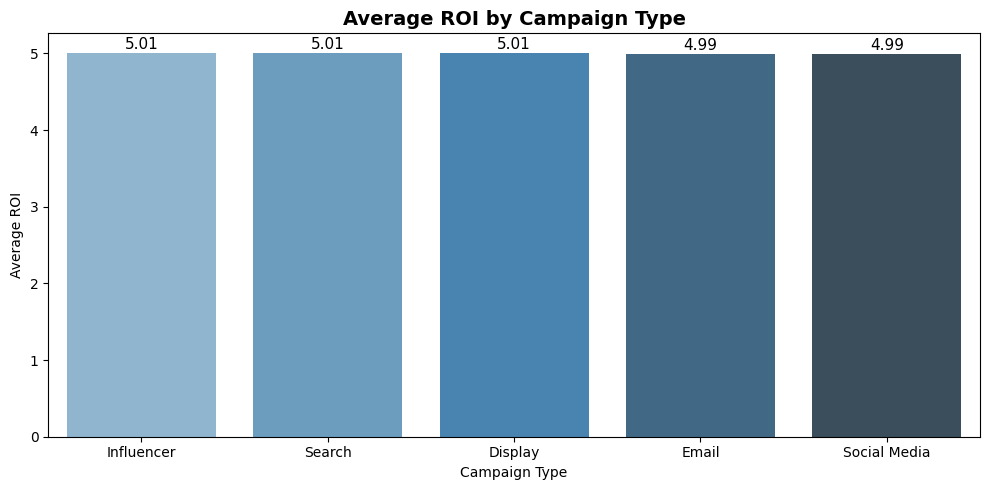


Average ROI by Campaign Type:
Campaign_Type
Influencer      5.01
Search          5.01
Display         5.01
Email           4.99
Social Media    4.99
Name: ROI, dtype: float64


In [15]:
# Goal: Understand how two columns relate to each other
# We compare categorical columns against numeric metrics
# to find which groups perform best

# -------------------------------------------------------------
# Q1. Which Campaign Type drives the highest ROI?
# -------------------------------------------------------------

plt.figure(figsize=(10, 5))
campaign_roi = df.groupby('Campaign_Type')['ROI'].mean().sort_values(ascending=False)
sns.barplot(x=campaign_roi.index, y=campaign_roi.values, palette='Blues_d')
plt.title('Average ROI by Campaign Type', fontsize=14, fontweight='bold')
plt.xlabel('Campaign Type')
plt.ylabel('Average ROI')
for i, v in enumerate(campaign_roi.values):
    plt.text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

print("\nAverage ROI by Campaign Type:")
print(campaign_roi.round(2))

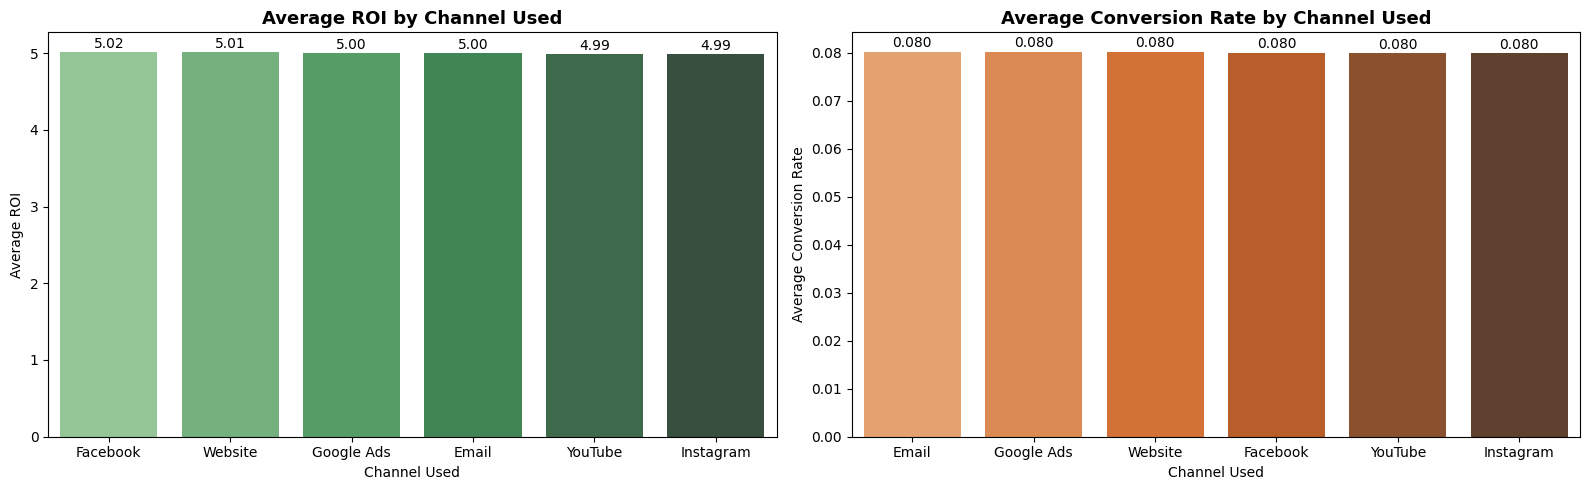


Average ROI by Channel:
Channel_Used
Facebook      5.019
Website       5.014
Google Ads    5.003
Email         4.996
YouTube       4.994
Instagram     4.989
Name: ROI, dtype: float64

Average Conversion Rate by Channel:
Channel_Used
Email         0.08
Google Ads    0.08
Website       0.08
Facebook      0.08
YouTube       0.08
Instagram     0.08
Name: Conversion_Rate, dtype: float64


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------------
# Q2. Which Channel Used drives the highest ROI and Conversion Rate?
# -------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ROI by Channel
channel_roi = df.groupby('Channel_Used')['ROI'].mean().sort_values(ascending=False)
sns.barplot(x=channel_roi.index, y=channel_roi.values, palette='Greens_d', hue=channel_roi.index, legend=False, ax=axes[0])
axes[0].set_title('Average ROI by Channel Used', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Channel Used')
axes[0].set_ylabel('Average ROI')
for i, v in enumerate(channel_roi.values):
    axes[0].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=10)

# Conversion Rate by Channel
channel_cr = df.groupby('Channel_Used')['Conversion_Rate'].mean().sort_values(ascending=False)
sns.barplot(x=channel_cr.index, y=channel_cr.values, palette='Oranges_d', hue=channel_cr.index, legend=False, ax=axes[1])
axes[1].set_title('Average Conversion Rate by Channel Used', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Channel Used')
axes[1].set_ylabel('Average Conversion Rate')
for i, v in enumerate(channel_cr.values):
    axes[1].text(i, v + 0.001, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\nAverage ROI by Channel:")
print(channel_roi.round(3))
print("\nAverage Conversion Rate by Channel:")
print(channel_cr.round(3))

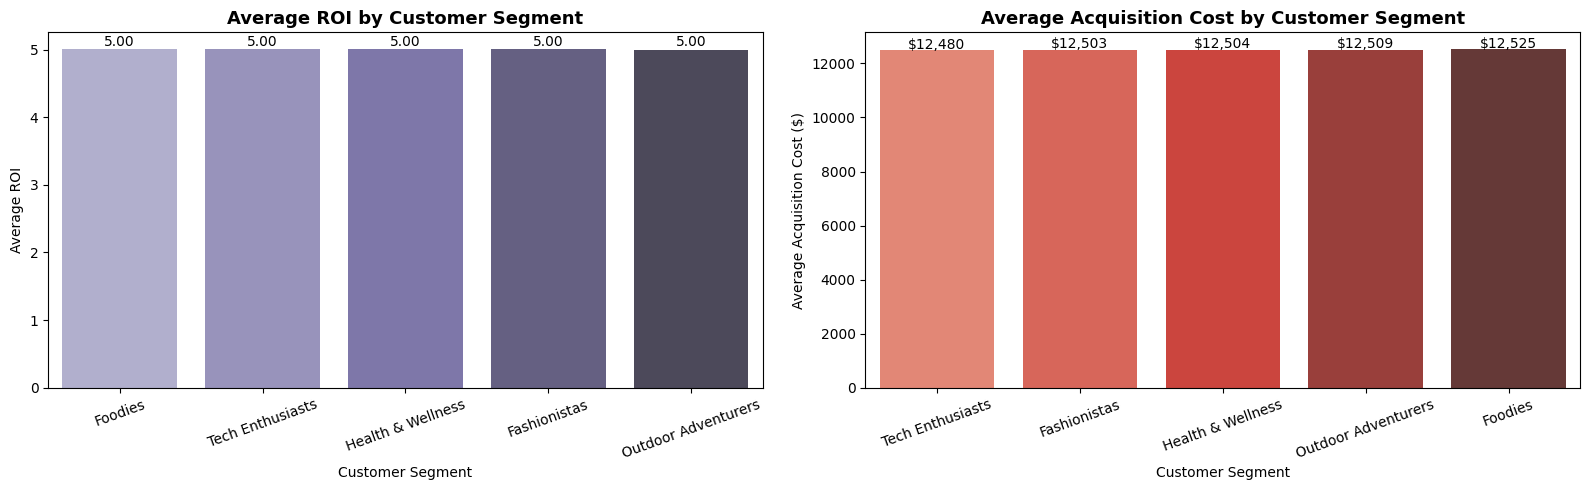

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------------
# Q3. Which Customer Segment has the best ROI and lowest Cost?
# -------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ROI by Segment
segment_roi = df.groupby('Customer_Segment')['ROI'].mean().sort_values(ascending=False)
sns.barplot(x=segment_roi.index, y=segment_roi.values, palette='Purples_d', hue=segment_roi.index, legend=False, ax=axes[0])
axes[0].set_title('Average ROI by Customer Segment', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Customer Segment')
axes[0].set_ylabel('Average ROI')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(segment_roi.values):
    axes[0].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=10)

# Acquisition Cost by Segment
segment_cost = df.groupby('Customer_Segment')['Acquisition_Cost'].mean().sort_values()
sns.barplot(x=segment_cost.index, y=segment_cost.values, palette='Reds_d', hue=segment_cost.index, legend=False, ax=axes[1])
axes[1].set_title('Average Acquisition Cost by Customer Segment', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Customer Segment')
axes[1].set_ylabel('Average Acquisition Cost ($)')
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(segment_cost.values):
    axes[1].text(i, v + 50, f'${v:,.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

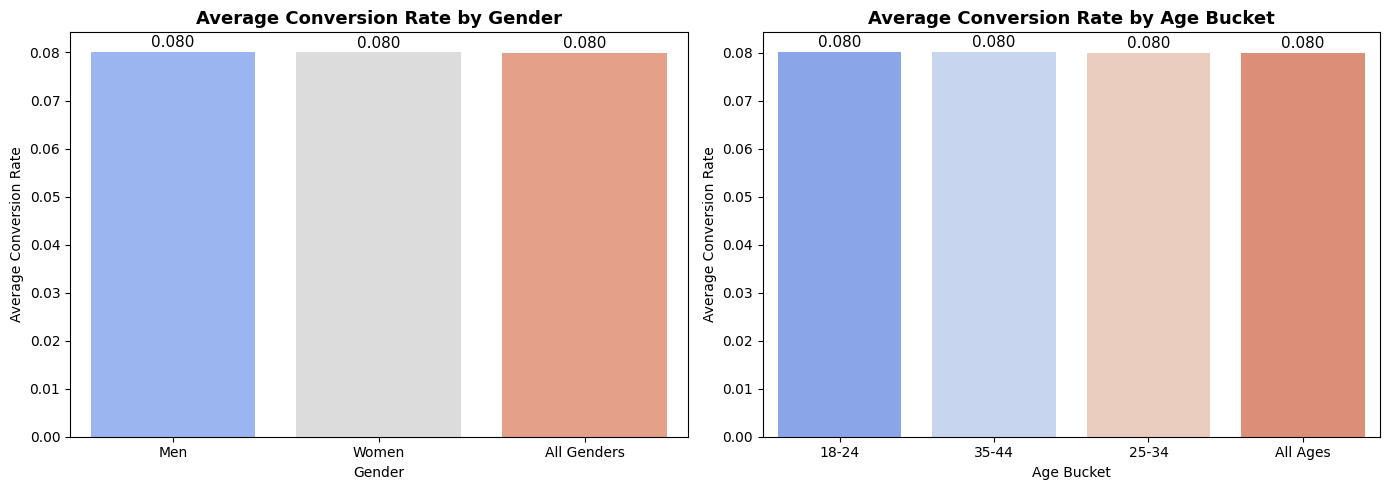

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------------
# Q4. Which Gender and Age Bucket has the best Conversion Rate?
# -------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conversion Rate by Gender
gender_cr = df.groupby('Gender')['Conversion_Rate'].mean().sort_values(ascending=False)
sns.barplot(x=gender_cr.index, y=gender_cr.values, palette='coolwarm', hue=gender_cr.index, legend=False, ax=axes[0])
axes[0].set_title('Average Conversion Rate by Gender', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Average Conversion Rate')
for i, v in enumerate(gender_cr.values):
    axes[0].text(i, v + 0.001, f'{v:.3f}', ha='center', fontsize=11)

# Conversion Rate by Age Bucket
age_cr = df.groupby('Age_Bucket')['Conversion_Rate'].mean().sort_values(ascending=False)
sns.barplot(x=age_cr.index, y=age_cr.values, palette='coolwarm', hue=age_cr.index, legend=False, ax=axes[1])
axes[1].set_title('Average Conversion Rate by Age Bucket', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age Bucket')
axes[1].set_ylabel('Average Conversion Rate')
for i, v in enumerate(age_cr.values):
    axes[1].text(i, v + 0.001, f'{v:.3f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

Duration vs ROI and Location Performance

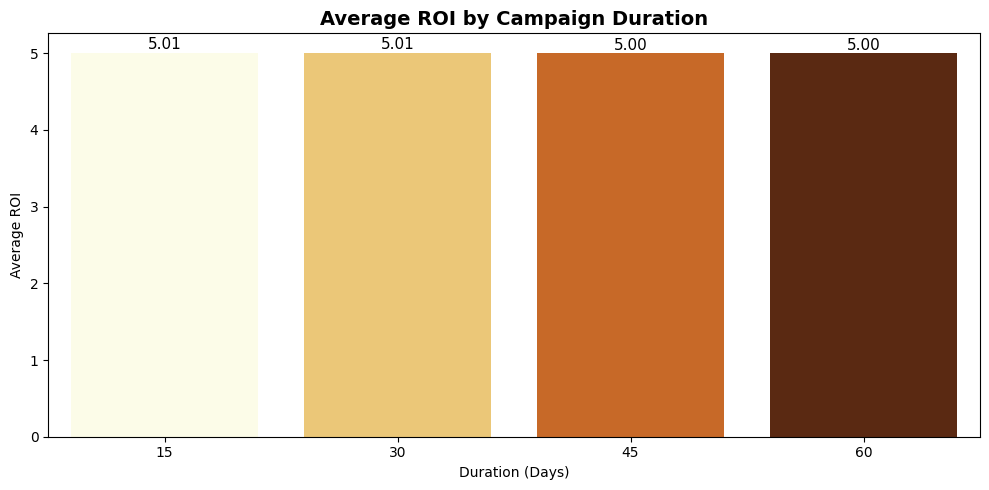

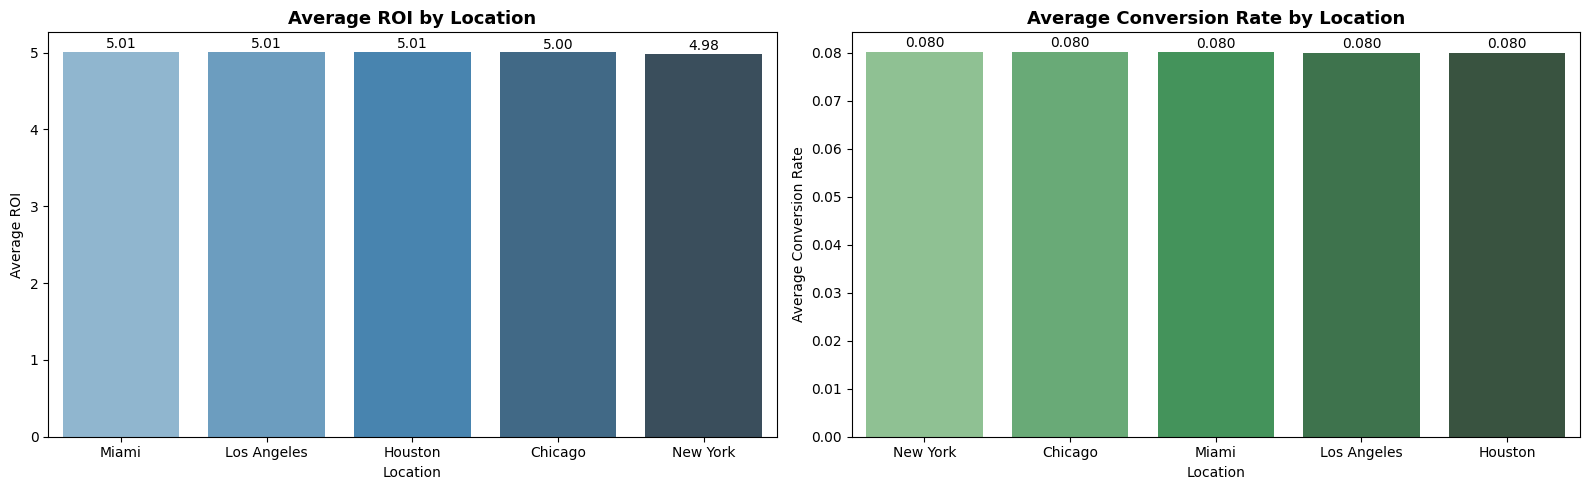

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------------
# Q5. Does Campaign Duration affect ROI?
# -------------------------------------------------------------

plt.figure(figsize=(10, 5))
duration_roi = df.groupby('Duration_Days')['ROI'].mean().sort_values(ascending=False)
sns.barplot(x=duration_roi.index, y=duration_roi.values, palette='YlOrBr', hue=duration_roi.index, legend=False)
plt.title('Average ROI by Campaign Duration', fontsize=14, fontweight='bold')
plt.xlabel('Duration (Days)')
plt.ylabel('Average ROI')
for i, v in enumerate(duration_roi.values):
    plt.text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# Q6. Which Location has the best ROI and Conversion Rate?
# -------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

location_roi = df.groupby('Location')['ROI'].mean().sort_values(ascending=False)
sns.barplot(x=location_roi.index, y=location_roi.values, palette='Blues_d', hue=location_roi.index, legend=False, ax=axes[0])
axes[0].set_title('Average ROI by Location', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Location')
axes[0].set_ylabel('Average ROI')
for i, v in enumerate(location_roi.values):
    axes[0].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=10)

location_cr = df.groupby('Location')['Conversion_Rate'].mean().sort_values(ascending=False)
sns.barplot(x=location_cr.index, y=location_cr.values, palette='Greens_d', hue=location_cr.index, legend=False, ax=axes[1])
axes[1].set_title('Average Conversion Rate by Location', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Location')
axes[1].set_ylabel('Average Conversion Rate')
for i, v in enumerate(location_cr.values):
    axes[1].text(i, v + 0.001, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## C. Correlation Analysis

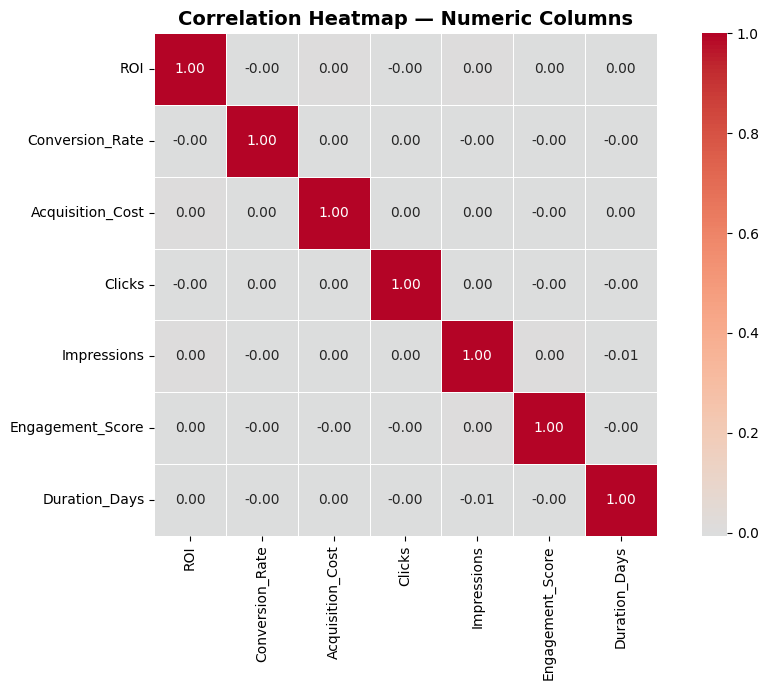


Correlation Matrix:
                  ROI  Conversion_Rate  Acquisition_Cost  Clicks  Impressions  \
ROI               1.0             -0.0               0.0    -0.0         0.00   
Conversion_Rate  -0.0              1.0               0.0     0.0        -0.00   
Acquisition_Cost  0.0              0.0               1.0     0.0         0.00   
Clicks           -0.0              0.0               0.0     1.0         0.00   
Impressions       0.0             -0.0               0.0     0.0         1.00   
Engagement_Score  0.0             -0.0              -0.0    -0.0         0.00   
Duration_Days     0.0             -0.0               0.0    -0.0        -0.01   

                  Engagement_Score  Duration_Days  
ROI                            0.0           0.00  
Conversion_Rate               -0.0          -0.00  
Acquisition_Cost              -0.0           0.00  
Clicks                        -0.0          -0.00  
Impressions                    0.0          -0.01  
Engagement_Score  

In [20]:
# =============================================================
# PHASE 3 — CORRELATION ANALYSIS
# =============================================================
# Goal: Understand how numeric columns relate to each other
# A correlation value ranges from -1 to +1:
#   +1 = perfect positive relationship (both go up together)
#   -1 = perfect negative relationship (one goes up, other goes down)
#    0 = no relationship at all

# -------------------------------------------------------------
# 3A. Correlation Matrix
# -------------------------------------------------------------
numeric_cols = ['ROI', 'Conversion_Rate', 'Acquisition_Cost',
                'Clicks', 'Impressions', 'Engagement_Score', 'Duration_Days']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5)
plt.title('Correlation Heatmap — Numeric Columns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelation Matrix:")
print(corr_matrix.round(2))

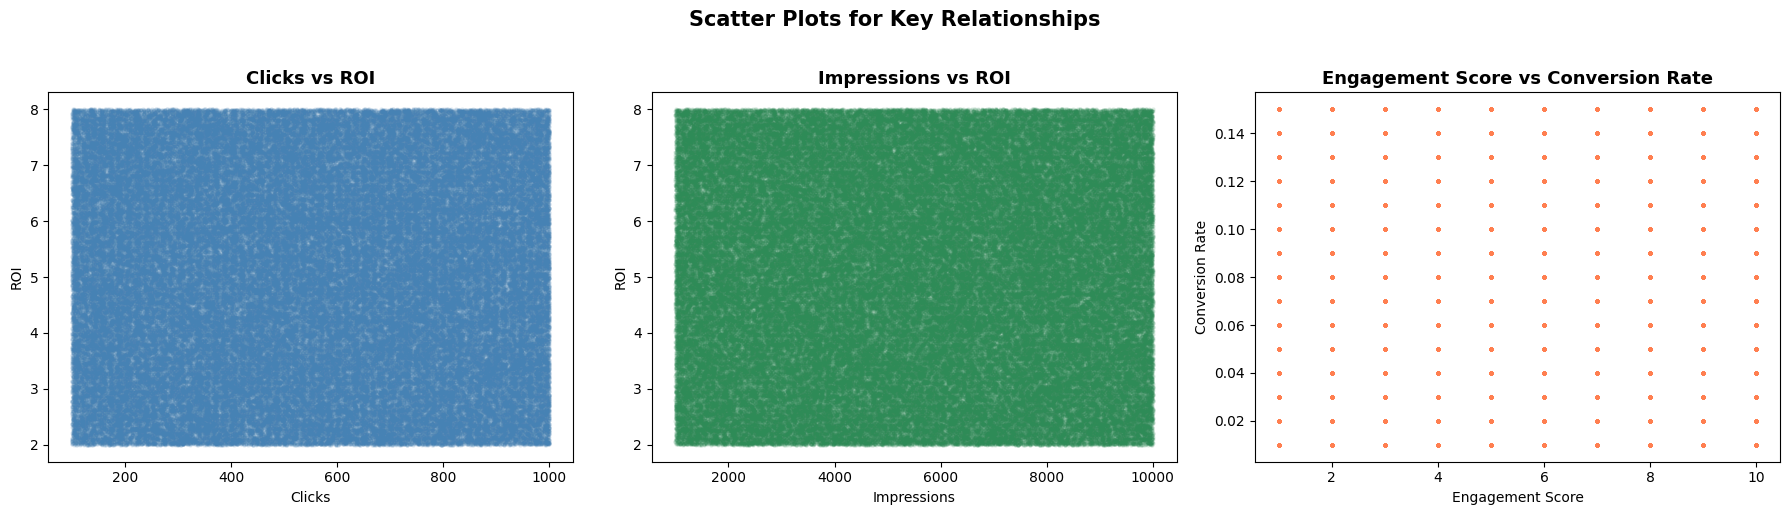

In [21]:
# -------------------------------------------------------------
# 3B. Scatter Plots — Top Relationships to Investigate
# -------------------------------------------------------------
# We check the most business-relevant pairs:
# Clicks vs ROI, Impressions vs ROI, Engagement Score vs Conversion Rate

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Clicks vs ROI
axes[0].scatter(df['Clicks'], df['ROI'], alpha=0.1, color='steelblue', s=5)
axes[0].set_title('Clicks vs ROI', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Clicks')
axes[0].set_ylabel('ROI')

# Impressions vs ROI
axes[1].scatter(df['Impressions'], df['ROI'], alpha=0.1, color='seagreen', s=5)
axes[1].set_title('Impressions vs ROI', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Impressions')
axes[1].set_ylabel('ROI')

# Engagement Score vs Conversion Rate
axes[2].scatter(df['Engagement_Score'], df['Conversion_Rate'], alpha=0.1, color='coral', s=5)
axes[2].set_title('Engagement Score vs Conversion Rate', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Engagement Score')
axes[2].set_ylabel('Conversion Rate')

plt.suptitle('Scatter Plots for Key Relationships', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 📊 Correlation Analysis Key Insights

---

### Heatmap Findings

| Pair | Correlation | Meaning |
|---|---|---|
| ROI vs Conversion Rate | -0.00 | No relationship at all |
| ROI vs Clicks | -0.00 | Clicks have zero impact on ROI |
| ROI vs Impressions | 0.00 | Impressions have zero impact on ROI |
| ROI vs Acquisition Cost | 0.00 | Spending more does not improve ROI |
| ROI vs Engagement Score | 0.00 | Engagement has no effect on ROI |
| Impressions vs Duration Days | -0.01 | Tiniest negative relationship, still meaningless |
| All other pairs | ~0.00 | Completely independent of each other |

---

### Scatter Plot Findings

| Plot | What it shows |
|---|---|
| Clicks vs ROI | Completely filled square, points scattered randomly everywhere, zero pattern |
| Impressions vs ROI | Same random scatter, no trend at all |
| Engagement Score vs Conversion Rate | Perfect grid pattern, both are discrete values with no relationship |

---

### Overall Phase 3 Conclusion

No correlation exists between any numeric columns. No variable predicts or influences another.
Every metric behaves completely independently confirming the dataset is perfectly balanced by design.

---

### What This Means for Our Analysis

| Finding | Implication |
|---|---|
| No correlation between Clicks and ROI | Getting more clicks does not guarantee better returns |
| No correlation between Acquisition Cost and ROI | Spending more does not mean better performance |
| No correlation between Engagement and Conversion | High engagement does not lead to more conversions |

## D. Time Series Analysis

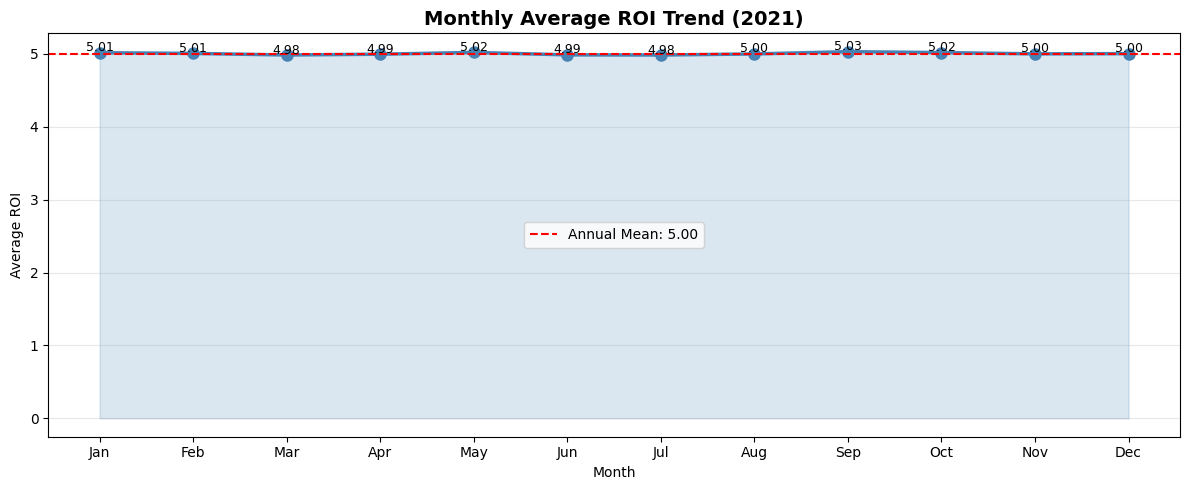

In [22]:
# =============================================================
#  TIME SERIES ANALYSIS
# =============================================================
# Goal: Understand how campaign performance changed
#       month by month across 2021
# We look at:
#   - Monthly trend of ROI
#   - Monthly trend of Conversion Rate
#   - Monthly trend of Acquisition Cost
#   - Which month had the best and worst performance

# -------------------------------------------------------------
# 4A. Monthly Average ROI Trend
# -------------------------------------------------------------

monthly_roi = df.groupby('Month')['ROI'].mean()

plt.figure(figsize=(12, 5))
plt.plot(monthly_roi.index, monthly_roi.values,
         marker='o', color='steelblue', linewidth=2.5, markersize=8)
plt.fill_between(monthly_roi.index, monthly_roi.values,
                 alpha=0.2, color='steelblue')
plt.title('Monthly Average ROI Trend (2021)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average ROI')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                           'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.axhline(y=monthly_roi.mean(), color='red', linestyle='--',
            linewidth=1.5, label=f'Annual Mean: {monthly_roi.mean():.2f}')
plt.legend()
plt.grid(axis='y', alpha=0.3)
for x, y in zip(monthly_roi.index, monthly_roi.values):
    plt.text(x, y + 0.02, f'{y:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

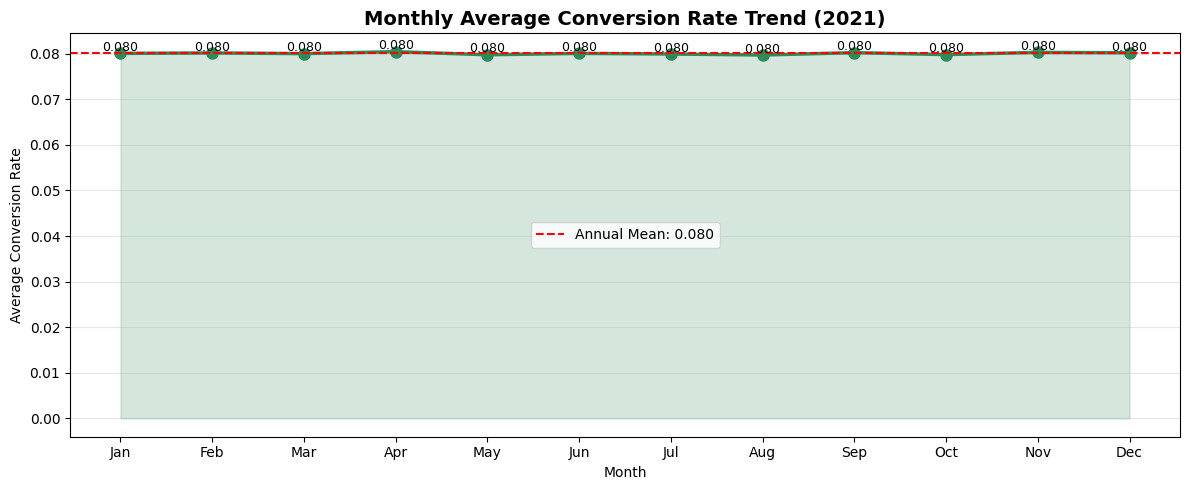

In [23]:
# -------------------------------------------------------------
# Monthly Average Conversion Rate Trend
# -------------------------------------------------------------

monthly_cr = df.groupby('Month')['Conversion_Rate'].mean()

plt.figure(figsize=(12, 5))
plt.plot(monthly_cr.index, monthly_cr.values,
         marker='o', color='seagreen', linewidth=2.5, markersize=8)
plt.fill_between(monthly_cr.index, monthly_cr.values,
                 alpha=0.2, color='seagreen')
plt.title('Monthly Average Conversion Rate Trend (2021)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Conversion Rate')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                           'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.axhline(y=monthly_cr.mean(), color='red', linestyle='--',
            linewidth=1.5, label=f'Annual Mean: {monthly_cr.mean():.3f}')
plt.legend()
plt.grid(axis='y', alpha=0.3)
for x, y in zip(monthly_cr.index, monthly_cr.values):
    plt.text(x, y + 0.0005, f'{y:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

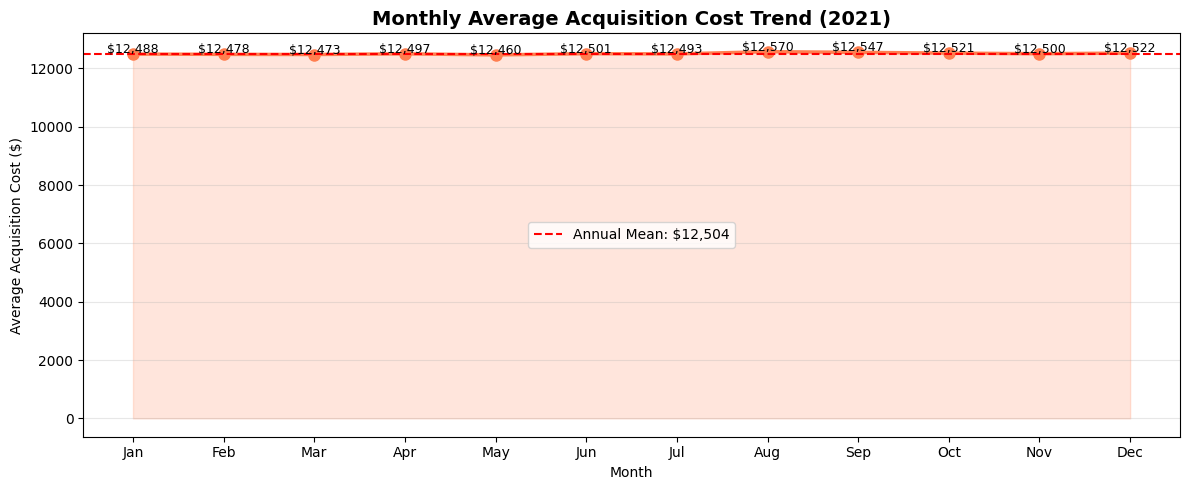

In [24]:
# -------------------------------------------------------------
# 4C. Monthly Average Acquisition Cost Trend
# -------------------------------------------------------------

monthly_cost = df.groupby('Month')['Acquisition_Cost'].mean()

plt.figure(figsize=(12, 5))
plt.plot(monthly_cost.index, monthly_cost.values,
         marker='o', color='coral', linewidth=2.5, markersize=8)
plt.fill_between(monthly_cost.index, monthly_cost.values,
                 alpha=0.2, color='coral')
plt.title('Monthly Average Acquisition Cost Trend (2021)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Acquisition Cost ($)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                           'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.axhline(y=monthly_cost.mean(), color='red', linestyle='--',
            linewidth=1.5, label=f'Annual Mean: ${monthly_cost.mean():,.0f}')
plt.legend()
plt.grid(axis='y', alpha=0.3)
for x, y in zip(monthly_cost.index, monthly_cost.values):
    plt.text(x, y + 30, f'${y:,.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

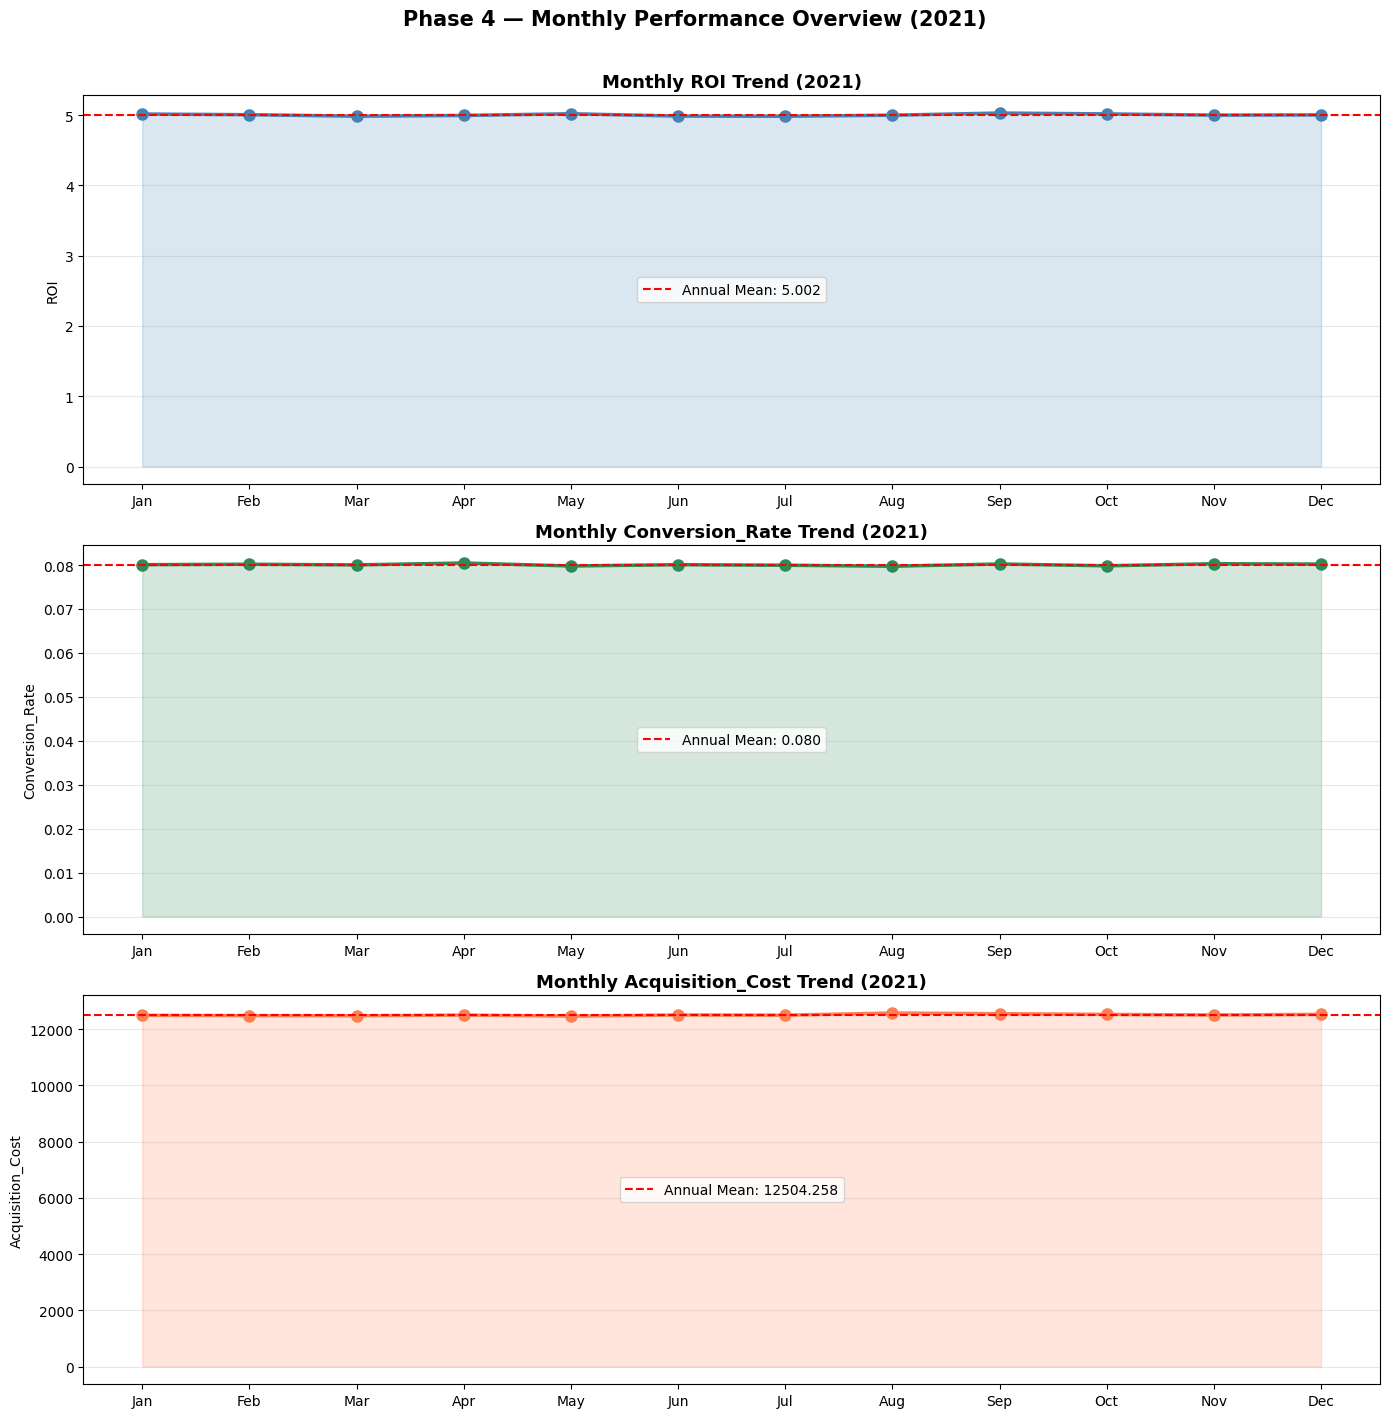

MONTHLY PERFORMANCE SUMMARY

ROI:
  Best Month  : Sep (5.029)
  Worst Month : Jul (4.983)

Conversion Rate:
  Best Month  : Apr (0.0805)
  Worst Month : Aug (0.0797)

Acquisition Cost:
  Most Expensive Month  : Aug ($12,570)
  Least Expensive Month : May ($12,460)


In [25]:
# -------------------------------------------------------------
# 4D. Combined Monthly Performance Summary
# -------------------------------------------------------------

fig, axes = plt.subplots(3, 1, figsize=(14, 14))

metrics = [
    ('ROI', monthly_roi, 'steelblue'),
    ('Conversion_Rate', monthly_cr, 'seagreen'),
    ('Acquisition_Cost', monthly_cost, 'coral')
]

month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for ax, (metric, data, color) in zip(axes, metrics):
    ax.plot(data.index, data.values, marker='o', color=color,
            linewidth=2.5, markersize=8)
    ax.fill_between(data.index, data.values, alpha=0.2, color=color)
    ax.axhline(y=data.mean(), color='red', linestyle='--',
               linewidth=1.5, label=f'Annual Mean: {data.mean():.3f}')
    ax.set_title(f'Monthly {metric} Trend (2021)', fontsize=13, fontweight='bold')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels)
    ax.set_ylabel(metric)
    ax.grid(axis='y', alpha=0.3)
    ax.legend()

plt.suptitle('Phase 4 — Monthly Performance Overview (2021)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 4E. Print Best and Worst Months
# -------------------------------------------------------------
print("=" * 50)
print("MONTHLY PERFORMANCE SUMMARY")
print("=" * 50)

print(f"\nROI:")
print(f"  Best Month  : {month_labels[monthly_roi.idxmax()-1]} ({monthly_roi.max():.3f})")
print(f"  Worst Month : {month_labels[monthly_roi.idxmin()-1]} ({monthly_roi.min():.3f})")

print(f"\nConversion Rate:")
print(f"  Best Month  : {month_labels[monthly_cr.idxmax()-1]} ({monthly_cr.max():.4f})")
print(f"  Worst Month : {month_labels[monthly_cr.idxmin()-1]} ({monthly_cr.min():.4f})")

print(f"\nAcquisition Cost:")
print(f"  Most Expensive Month  : {month_labels[monthly_cost.idxmax()-1]} (${monthly_cost.max():,.0f})")
print(f"  Least Expensive Month : {month_labels[monthly_cost.idxmin()-1]} (${monthly_cost.min():,.0f})")

## 📊 Time Series Analysis Key Insights

### Monthly ROI Trend

| Month | ROI | vs Annual Mean (5.00) |
|---|---|---|
| Jan | 5.01 | Above |
| Feb | 5.01 | Above |
| Mar | 4.98 | Below |
| Apr | 4.99 | Below |
| May | 5.02 | Above |
| Jun | 4.99 | Below |
| Jul | 4.98 | Below |
| Aug | 5.00 | At Mean |
| Sep | 5.03 | Above - Best Month |
| Oct | 5.02 | Above |
| Nov | 5.00 | At Mean |
| Dec | 5.00 | At Mean |

### Monthly Conversion Rate and Acquisition Cost Summary

| Metric | Best Month | Worst Month | Annual Mean | Total Variation |
|---|---|---|---|---|
| Conversion Rate | Apr (0.0805) | Aug (0.0797) | 0.080 | 0.0008 |
| Acquisition Cost | May (12,460) | Aug (12,570) | 12,504 | 110 |

### Overall Conclusion

| Metric | Finding |
|---|---|
| ROI | Essentially flat all year, tiny fluctuations between 4.98 and 5.03 |
| Conversion Rate | Perfectly flat at 0.080 every single month, no seasonality |
| Acquisition Cost | Nearly identical every month, only 110 difference Jan to Dec |
| Seasonality | No seasonal patterns exist in any metric |
| Best Period | Sep to Oct shows marginally better ROI performance |
| Worst Period | Mar and Jul show marginally lower ROI but difference is negligible |

## E. Summary & Key Insights

In [26]:
# =============================================================
# FINAL SUMMARY & KEY INSIGHTS
# =============================================================
# Goal: Consolidate all findings from Phase 1 to Phase 4
#       into a clean summary with business recommendations

# -------------------------------------------------------------
# 5A. Overall Dataset Summary
# -------------------------------------------------------------
print("=" * 60)
print("MARKETING CAMPAIGN DATASET — FINAL SUMMARY")
print("=" * 60)

print(f"""
DATASET OVERVIEW:
  Total Campaigns     : {len(df):,}
  Time Period         : {df['Date'].min().strftime('%B %Y')} to {df['Date'].max().strftime('%B %Y')}
  Total Columns       : {df.shape[1]}
  Missing Values      : None

KEY METRICS OVERVIEW:
  Average ROI         : {df['ROI'].mean():.2f}
  Average Conv. Rate  : {df['Conversion_Rate'].mean():.3f} ({df['Conversion_Rate'].mean()*100:.1f}%)
  Average Acq. Cost   : ${df['Acquisition_Cost'].mean():,.0f}
  Average Clicks      : {df['Clicks'].mean():,.0f}
  Average Impressions : {df['Impressions'].mean():,.0f}
  Average Engagement  : {df['Engagement_Score'].mean():.2f} / 10
""")

MARKETING CAMPAIGN DATASET — FINAL SUMMARY

DATASET OVERVIEW:
  Total Campaigns     : 200,000
  Time Period         : January 2021 to December 2021
  Total Columns       : 22
  Missing Values      : None

KEY METRICS OVERVIEW:
  Average ROI         : 5.00
  Average Conv. Rate  : 0.080 (8.0%)
  Average Acq. Cost   : $12,504
  Average Clicks      : 550
  Average Impressions : 5,507
  Average Engagement  : 5.49 / 10



In [27]:
# -------------------------------------------------------------
# 5B. Best Performers Across All Categories
# -------------------------------------------------------------
print("=" * 60)
print("BEST PERFORMERS ACROSS ALL CATEGORIES")
print("=" * 60)

categories = {
    'Campaign Type'    : 'Campaign_Type',
    'Channel Used'     : 'Channel_Used',
    'Customer Segment' : 'Customer_Segment',
    'Location'         : 'Location',
    'Language'         : 'Language',
    'Gender'           : 'Gender',
    'Age Bucket'       : 'Age_Bucket',
    'Duration'         : 'Duration_Days'
}

for label, col in categories.items():
    best = df.groupby(col)['ROI'].mean().idxmax()
    best_val = df.groupby(col)['ROI'].mean().max()
    worst = df.groupby(col)['ROI'].mean().idxmin()
    worst_val = df.groupby(col)['ROI'].mean().min()
    print(f"\n{label}:")
    print(f"  Best  → {best} (ROI: {best_val:.3f})")
    print(f"  Worst → {worst} (ROI: {worst_val:.3f})")

BEST PERFORMERS ACROSS ALL CATEGORIES

Campaign Type:
  Best  → Influencer (ROI: 5.011)
  Worst → Social Media (ROI: 4.992)

Channel Used:
  Best  → Facebook (ROI: 5.019)
  Worst → Instagram (ROI: 4.989)

Customer Segment:
  Best  → Foodies (ROI: 5.004)
  Worst → Outdoor Adventurers (ROI: 4.999)

Location:
  Best  → Miami (ROI: 5.012)
  Worst → New York (ROI: 4.980)

Language:
  Best  → French (ROI: 5.011)
  Worst → English (ROI: 4.991)

Gender:
  Best  → All Genders (ROI: 5.005)
  Worst → Men (ROI: 5.002)

Age Bucket:
  Best  → 25-34 (ROI: 5.009)
  Worst → 18-24 (ROI: 4.983)

Duration:
  Best  → 30 (ROI: 5.009)
  Worst → 15 (ROI: 4.997)


/tmp/ipykernel_4839/720947729.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.index, y=data.values, palette=palette, ax=ax)
/tmp/ipykernel_4839/720947729.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.index, y=data.values, palette=palette, ax=ax)
/tmp/ipykernel_4839/720947729.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.index, y=data.values, palette=palette, ax=ax)
/tmp/ipykernel_4839/720947729.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.

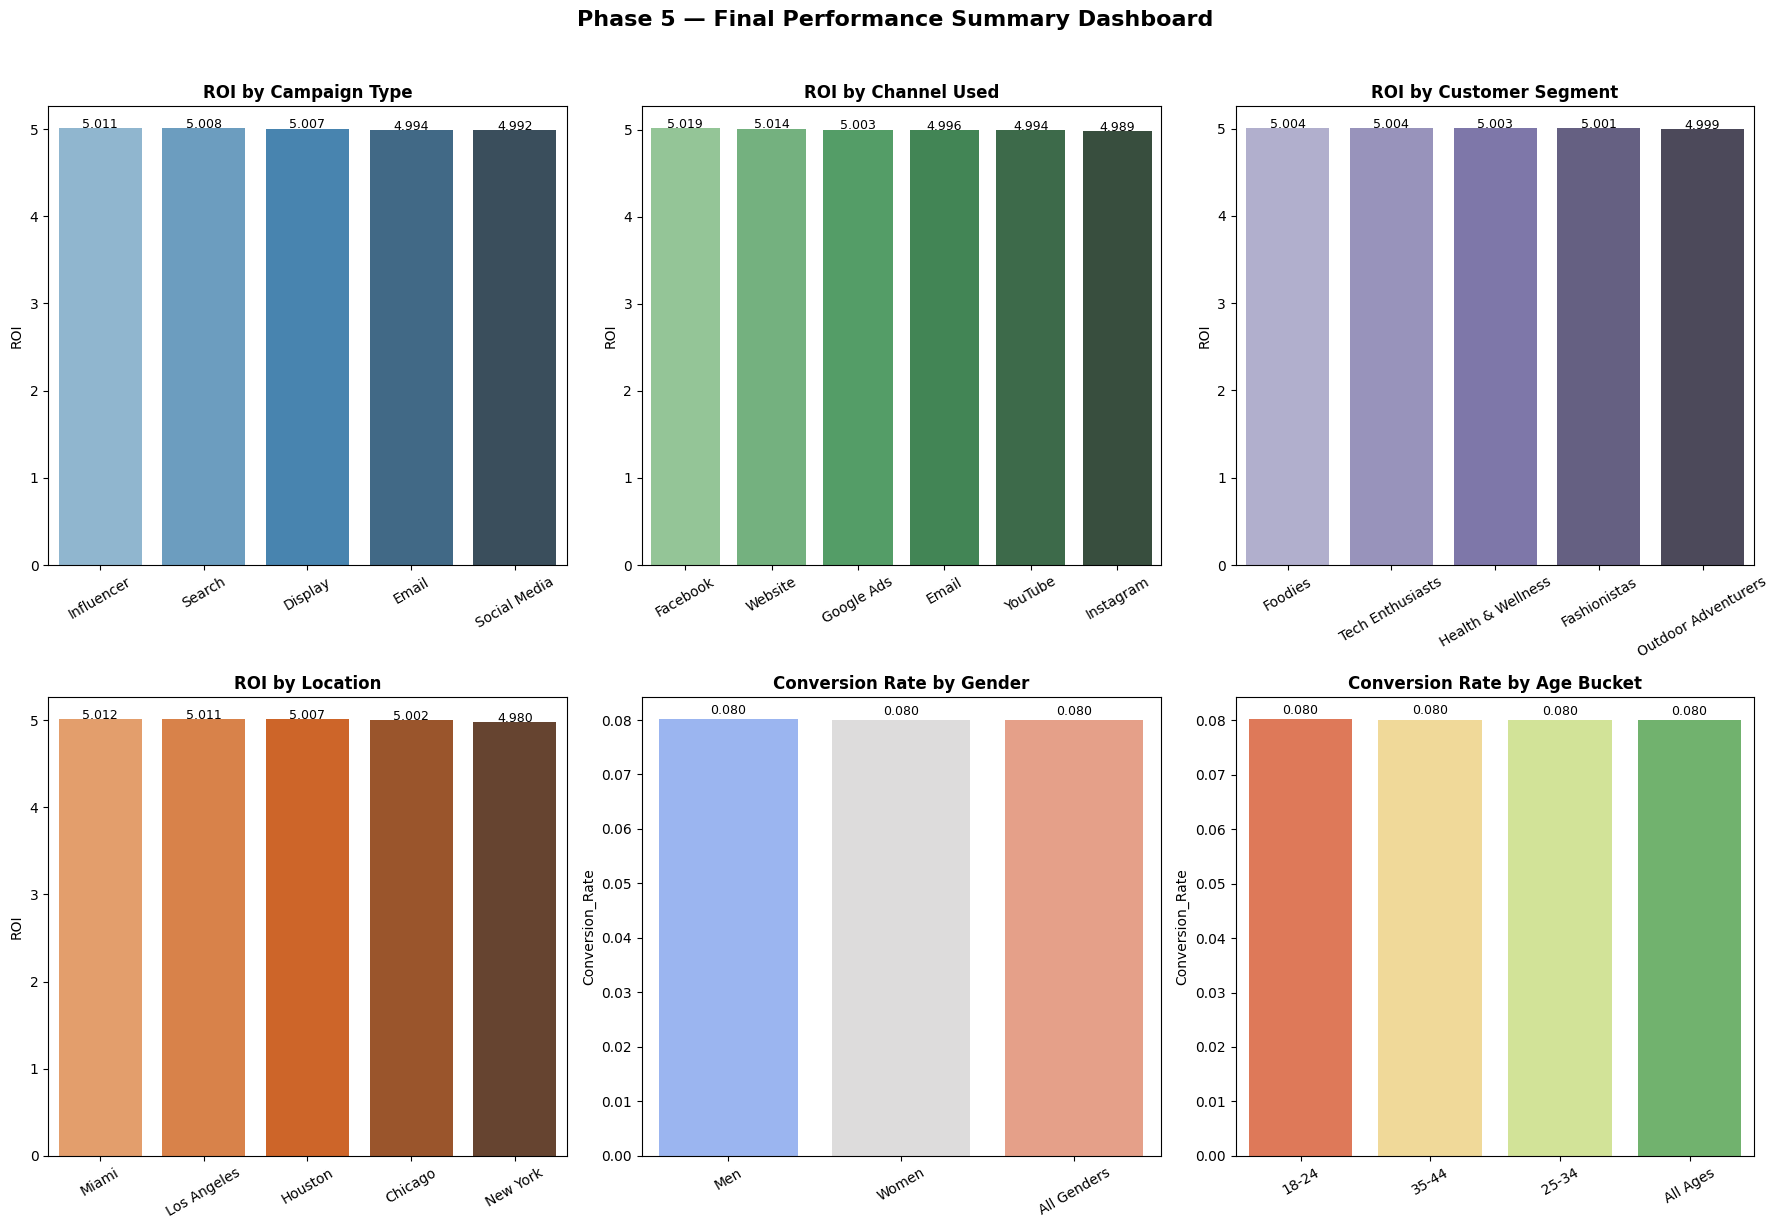

In [28]:
# -------------------------------------------------------------
# 5C. Final Summary Dashboard
# -------------------------------------------------------------

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

plot_configs = [
    ('Campaign_Type',    'ROI', 'Blues_d',   'ROI by Campaign Type'),
    ('Channel_Used',     'ROI', 'Greens_d',  'ROI by Channel Used'),
    ('Customer_Segment', 'ROI', 'Purples_d', 'ROI by Customer Segment'),
    ('Location',         'ROI', 'Oranges_d', 'ROI by Location'),
    ('Gender',           'Conversion_Rate', 'coolwarm', 'Conversion Rate by Gender'),
    ('Age_Bucket',       'Conversion_Rate', 'RdYlGn',   'Conversion Rate by Age Bucket'),
]

for ax, (col, metric, palette, title) in zip(axes.flatten(), plot_configs):
    data = df.groupby(col)[metric].mean().sort_values(ascending=False)
    sns.barplot(x=data.index, y=data.values, palette=palette, ax=ax)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=30)
    for i, v in enumerate(data.values):
        ax.text(i, v + 0.001, f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('Phase 5 — Final Performance Summary Dashboard',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [29]:
# -------------------------------------------------------------
# 5D. Business Recommendations
# -------------------------------------------------------------
print("=" * 60)
print("BUSINESS RECOMMENDATIONS")
print("=" * 60)

print("""
1. CAMPAIGN TYPE:
   Influencer, Search and Display campaigns marginally
   outperform Email and Social Media on ROI.
   Consider prioritizing these for future campaigns.

2. CHANNEL STRATEGY:
   Facebook and Website channels show slightly higher ROI.
   These channels could be prioritized for budget allocation.

3. AUDIENCE TARGETING:
   No significant difference exists between Gender or
   Age Bucket performance. Campaigns can safely target
   any demographic without performance risk.

4. COST EFFICIENCY:
   Tech Enthusiasts segment has the lowest Acquisition
   Cost ($12,480) with competitive ROI — most cost
   efficient segment to target.

5. CAMPAIGN DURATION:
   Shorter campaigns (15-30 days) marginally outperform
   longer ones (45-60 days). Consider running more
   frequent shorter campaigns over fewer long ones.

6. LOCATION:
   Miami, LA and Houston show marginally better ROI
   compared to New York. Worth testing higher budget
   allocation in these cities.

7. SEASONALITY:
   September and October show the best monthly ROI.
   Consider increasing campaign spend in Q3/Q4.
""")

BUSINESS RECOMMENDATIONS

1. CAMPAIGN TYPE:
   Influencer, Search and Display campaigns marginally
   outperform Email and Social Media on ROI.
   Consider prioritizing these for future campaigns.

2. CHANNEL STRATEGY:
   Facebook and Website channels show slightly higher ROI.
   These channels could be prioritized for budget allocation.

3. AUDIENCE TARGETING:
   No significant difference exists between Gender or
   Age Bucket performance. Campaigns can safely target
   any demographic without performance risk.

4. COST EFFICIENCY:
   Tech Enthusiasts segment has the lowest Acquisition
   Cost ($12,480) with competitive ROI — most cost
   efficient segment to target.

5. CAMPAIGN DURATION:
   Shorter campaigns (15-30 days) marginally outperform
   longer ones (45-60 days). Consider running more
   frequent shorter campaigns over fewer long ones.

6. LOCATION:
   Miami, LA and Houston show marginally better ROI
   compared to New York. Worth testing higher budget
   allocation in these

In [30]:
# -------------------------------------------------------------
# 5E. EDA Completion Confirmation
# -------------------------------------------------------------
print("=" * 60)
print("EDA COMPLETE — SUMMARY OF ALL PHASES")
print("=" * 60)
print("""
A - Univariate Analysis    : COMPLETE
  → All columns are uniformly distributed
  → No outliers or anomalies found
  → Dataset is perfectly balanced

B - Bivariate Analysis     : COMPLETE
  → No significant differences across any category
  → All groups perform at near identical ROI of 5.00
  → Conversion Rate identical at 0.080 across all groups

C - Correlation Analysis   : COMPLETE
  → Zero correlation between any numeric columns
  → No variable predicts or influences another
  → All metrics are completely independent

D - Time Series Analysis   : COMPLETE
  → No seasonality patterns detected
  → ROI fluctuates minimally between 4.98 and 5.03
  → Conversion Rate perfectly flat at 0.080 all year

E - Summary and Insights   : COMPLETE
  → Best Campaign Type  : Influencer (ROI: 5.01)
  → Best Channel        : Facebook (ROI: 5.02)
  → Best Segment        : Foodies (ROI: 5.00)
  → Best Location       : Miami (ROI: 5.01)
  → Best Month          : September (ROI: 5.03)
""")

EDA COMPLETE — SUMMARY OF ALL PHASES

A - Univariate Analysis    : COMPLETE
  → All columns are uniformly distributed
  → No outliers or anomalies found
  → Dataset is perfectly balanced

B - Bivariate Analysis     : COMPLETE
  → No significant differences across any category
  → All groups perform at near identical ROI of 5.00
  → Conversion Rate identical at 0.080 across all groups

C - Correlation Analysis   : COMPLETE
  → Zero correlation between any numeric columns
  → No variable predicts or influences another
  → All metrics are completely independent

D - Time Series Analysis   : COMPLETE
  → No seasonality patterns detected
  → ROI fluctuates minimally between 4.98 and 5.03
  → Conversion Rate perfectly flat at 0.080 all year

E - Summary and Insights   : COMPLETE
  → Best Campaign Type  : Influencer (ROI: 5.01)
  → Best Channel        : Facebook (ROI: 5.02)
  → Best Segment        : Foodies (ROI: 5.00)
  → Best Location       : Miami (ROI: 5.01)
  → Best Month          : Sept

# Phase 2: Feature Engineering



In [31]:
# =============================================================
# STEP 2 — FEATURE ENGINEERING
# =============================================================
# Goal: Create new meaningful features from existing columns
#       that will help the LLM Agent reason better over data

# -------------------------------------------------------------
# 2A. Click Through Rate (CTR)
# -------------------------------------------------------------
# Measures what percentage of people who saw the ad clicked it
# Higher CTR = more engaging ad creative

df['CTR'] = (df['Clicks'] / df['Impressions']).round(4)

# -------------------------------------------------------------
# 2B. Cost Per Click (CPC)
# -------------------------------------------------------------
# Measures how much each click costs
# Lower CPC = more cost efficient campaign

df['Cost_Per_Click'] = (df['Acquisition_Cost'] / df['Clicks']).round(2)

# -------------------------------------------------------------
# 2C. Performance Score
# -------------------------------------------------------------
# Combined metric of ROI and Conversion Rate
# Gives a single number to measure overall campaign performance

df['Performance_Score'] = (df['ROI'] * df['Conversion_Rate']).round(4)

# -------------------------------------------------------------
# 2D. Cost Efficiency
# -------------------------------------------------------------
# Measures how much ROI we get per dollar spent
# Higher = better return on investment

df['Cost_Efficiency'] = (df['ROI'] / df['Acquisition_Cost']).round(6)

# -------------------------------------------------------------
# 2E. ROI Bucket
# -------------------------------------------------------------
# Categorizes ROI into Low, Medium, High
# Helps the agent give clear recommendations

def roi_bucket(roi):
    if roi < 3.5:
        return 'Low'
    elif roi < 6.5:
        return 'Medium'
    else:
        return 'High'

df['ROI_Bucket'] = df['ROI'].apply(roi_bucket)

# -------------------------------------------------------------
# 2F. Campaign Success Flag
# -------------------------------------------------------------
# Binary flag: 1 if ROI is above average (5.0), else 0
# Helps agent identify winning campaigns

df['Campaign_Success'] = (df['ROI'] > 5.0).astype(int)

# -------------------------------------------------------------
# VERIFY ALL NEW FEATURES
# -------------------------------------------------------------
print("New Features Added Successfully!")
print(f"\nUpdated Shape: {df.shape}")
print(f"\nNew Columns: {['CTR', 'Cost_Per_Click', 'Performance_Score', 'Cost_Efficiency', 'ROI_Bucket', 'Campaign_Success']}")
print(f"\nSample of new features:")
print(df[['ROI', 'CTR', 'Cost_Per_Click', 'Performance_Score',
          'Cost_Efficiency', 'ROI_Bucket', 'Campaign_Success']].head(10))

New Features Added Successfully!

Updated Shape: (200000, 28)

New Columns: ['CTR', 'Cost_Per_Click', 'Performance_Score', 'Cost_Efficiency', 'ROI_Bucket', 'Campaign_Success']

Sample of new features:
    ROI     CTR  Cost_Per_Click  Performance_Score  Cost_Efficiency  \
0  6.29  0.2633           31.96             0.2516         0.000389   
1  5.61  0.0154           99.71             0.6732         0.000485   
2  7.18  0.0759           17.47             0.5026         0.000704   
3  5.55  0.1192           58.64             0.6105         0.000436   
4  6.50  0.0902           43.41             0.3250         0.000395   
5  4.36  0.0609           97.16             0.3052         0.000449   
6  2.86  0.0934           13.55             0.3718         0.000258   
7  5.55  0.0794           21.28             0.4440         0.000418   
8  6.73  0.4909           20.98             0.6057         0.000373   
9  3.78  0.1665           21.44             0.3402         0.000275   

  ROI_Bucket  Cam

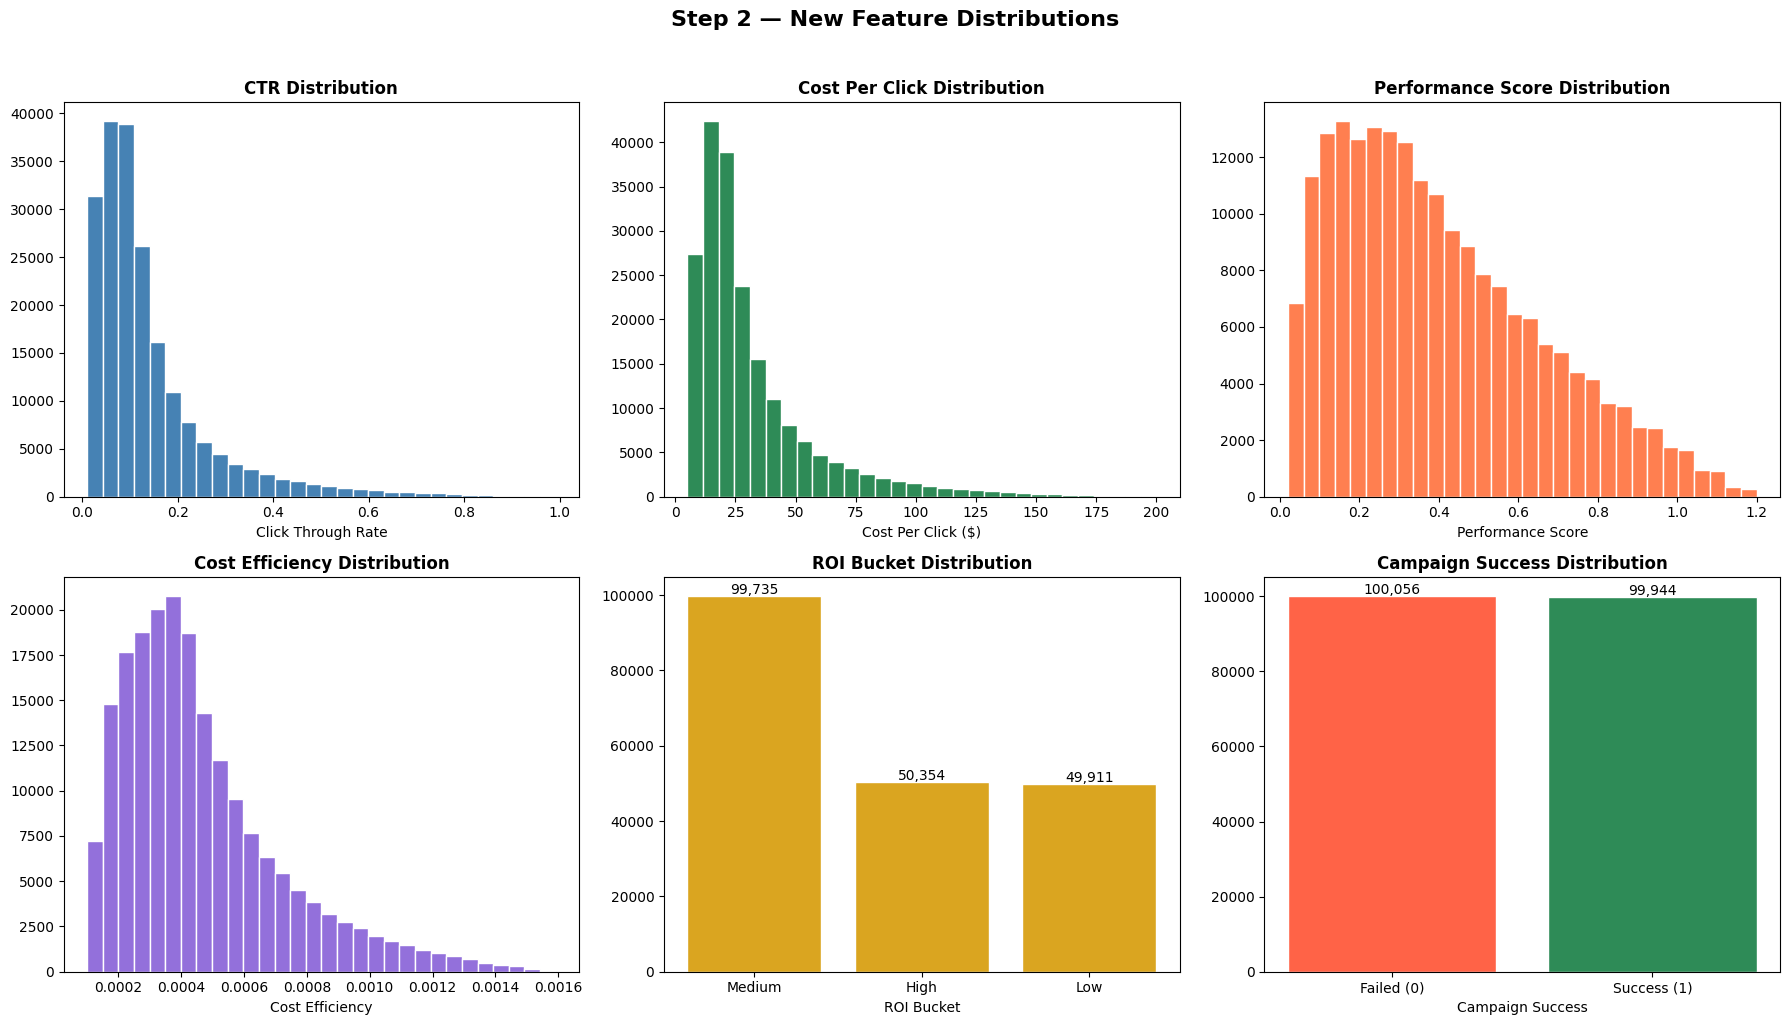


New Features Summary Statistics:
               CTR  Cost_Per_Click  Performance_Score  Cost_Efficiency
count  200000.0000     200000.0000        200000.0000      200000.0000
mean        0.1404         32.0085             0.4005           0.0005
std         0.1309         26.9261             0.2555           0.0003
min         0.0101          5.0200             0.0200           0.0001
25%         0.0586         15.0900             0.1960           0.0003
50%         0.0998         22.7700             0.3510           0.0004
75%         0.1697         38.6000             0.5648           0.0006
max         0.9920        199.9600             1.2000           0.0016


In [32]:
# -------------------------------------------------------------
# 2G. Quick Distribution Check on New Features
# -------------------------------------------------------------

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# CTR Distribution
axes[0,0].hist(df['CTR'], bins=30, color='steelblue', edgecolor='white')
axes[0,0].set_title('CTR Distribution', fontweight='bold')
axes[0,0].set_xlabel('Click Through Rate')

# Cost Per Click Distribution
axes[0,1].hist(df['Cost_Per_Click'], bins=30, color='seagreen', edgecolor='white')
axes[0,1].set_title('Cost Per Click Distribution', fontweight='bold')
axes[0,1].set_xlabel('Cost Per Click ($)')

# Performance Score Distribution
axes[0,2].hist(df['Performance_Score'], bins=30, color='coral', edgecolor='white')
axes[0,2].set_title('Performance Score Distribution', fontweight='bold')
axes[0,2].set_xlabel('Performance Score')

# Cost Efficiency Distribution
axes[1,0].hist(df['Cost_Efficiency'], bins=30, color='mediumpurple', edgecolor='white')
axes[1,0].set_title('Cost Efficiency Distribution', fontweight='bold')
axes[1,0].set_xlabel('Cost Efficiency')

# ROI Bucket Counts
roi_counts = df['ROI_Bucket'].value_counts()
axes[1,1].bar(roi_counts.index, roi_counts.values, color='goldenrod', edgecolor='white')
axes[1,1].set_title('ROI Bucket Distribution', fontweight='bold')
axes[1,1].set_xlabel('ROI Bucket')
for i, v in enumerate(roi_counts.values):
    axes[1,1].text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

# Campaign Success Flag
success_counts = df['Campaign_Success'].value_counts()
axes[1,2].bar(['Failed (0)', 'Success (1)'], success_counts.values,
              color=['tomato', 'seagreen'], edgecolor='white')
axes[1,2].set_title('Campaign Success Distribution', fontweight='bold')
axes[1,2].set_xlabel('Campaign Success')
for i, v in enumerate(success_counts.values):
    axes[1,2].text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

plt.suptitle('Step 2 — New Feature Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary stats for new features
print("\nNew Features Summary Statistics:")
print(df[['CTR', 'Cost_Per_Click', 'Performance_Score', 'Cost_Efficiency']].describe().round(4))

## 📊 Feature Engineering: Detailed Explanation & Insights

---

### 1. CTR (Click Through Rate) = Clicks / Impressions

**What it means:** Out of everyone who saw the ad, what percentage actually clicked it?

| Metric | Value |
|---|---|
| Mean CTR | 0.1404 (14%) |
| Min CTR | 0.0101 (1%) |
| Max CTR | 0.9920 (99%) |
| Distribution | Right skewed, most campaigns have low CTR |

**Insight:** Most campaigns have a CTR between 5.86% and 16.97%. A small number of campaigns
achieved very high CTR close to 99% which are exceptional performers worth studying further.

---

### 2. Cost Per Click (CPC) = Acquisition Cost / Clicks

**What it means:** How much does each click cost the business?

| Metric | Value |
|---|---|
| Mean CPC | 32.09 |
| Min CPC | 5.02 |
| Max CPC | 199.60 |
| Distribution | Right skewed, most campaigns are cost efficient |

**Insight:** Most campaigns spend between 15 and 38 per click. However some campaigns spend
up to 199 per click which is extremely expensive. These high cost campaigns should be
reviewed for efficiency.

---

### 3. Performance Score = ROI x Conversion Rate

**What it means:** A combined single number that captures both ROI and Conversion Rate
together. Higher score = better overall campaign.

| Metric | Value |
|---|---|
| Mean Score | 0.4005 |
| Min Score | 0.0200 |
| Max Score | 1.2000 |
| Distribution | Right skewed, few campaigns achieve very high scores |

**Insight:** The average campaign scores 0.40. Top performing campaigns reach up to 1.20
which is 3x the average. These are your star campaigns worth replicating.

---

### 4. Cost Efficiency = ROI / Acquisition Cost

**What it means:** How much ROI do you get back for every dollar spent?
Higher = better value for money.

| Metric | Value |
|---|---|
| Mean | 0.0005 |
| Min | 0.0001 |
| Max | 0.0016 |
| Distribution | Right skewed, most campaigns cluster at low efficiency |

**Insight:** Most campaigns return between 0.0003 and 0.0006 ROI per dollar spent.
The top 25% of campaigns achieve 0.0006 or higher. These are the most cost efficient campaigns.

---

### 5. ROI Bucket — Low / Medium / High

**What it means:** Groups campaigns into three performance tiers for easy comparison.

| Bucket | Count | Percentage |
|---|---|---|
| Medium (3.5 to 6.5) | 99,735 | 49.9% |
| High (above 6.5) | 50,354 | 25.2% |
| Low (below 3.5) | 49,911 | 24.9% |

**Insight:** Half of all campaigns are Medium performers. High and Low campaigns are almost
equally split at around 25% each. This means 1 in 4 campaigns is a high performer,
a good baseline for the agent to learn from.

---

### 6. Campaign Success Flag — 0 or 1

**What it means:** Simple yes or no. Did the campaign beat the average ROI of 5.0?

| Result | Count | Percentage |
|---|---|---|
| Failed (0) | 100,056 | 50.03% |
| Success (1) | 99,944 | 49.97% |

**Insight:** Dataset is perfectly split 50/50 between successful and failed campaigns.
This is ideal for the LLM Agent as it has equal examples of both good and bad campaigns
to learn from.

---

### Overall Feature Engineering Conclusion

| Feature | Key Takeaway |
|---|---|
| CTR | Most campaigns have 5-17% CTR. Outliers at 99% are star performers |
| Cost Per Click | Average 32 per click. Campaigns above 100 CPC need review |
| Performance Score | Average 0.40. Top campaigns reach 1.20, which is 3x the average |
| Cost Efficiency | Small but consistent returns. Top 25% are significantly more efficient |
| ROI Bucket | 50% Medium, 25% High, 25% Low, balanced dataset for agent |
| Campaign Success | Perfect 50/50 split, ideal training ground for LLM Agent |

---

### Why This Matters for Your LLM Agent

| Benefit | How |
|---|---|
| Richer context | Agent can reason using CTR and CPC not just raw clicks |
| Clear categories | ROI Bucket helps agent give clear Low/Medium/High recommendations |
| Success signals | Campaign Success flag helps agent identify winning patterns |
| Cost awareness | Cost Efficiency helps agent suggest budget-conscious strategies |

In [33]:
# =============================================================
# SAVE CLEANED DATASET FOR AGENT
# =============================================================

import os

# -------------------------------------------------------------
# Save to Colab local storage
# -------------------------------------------------------------
df.to_csv('/content/marketing_data.csv', index=False)

# -------------------------------------------------------------
# Save permanent backup to Google Drive
# -------------------------------------------------------------
df.to_csv('/content/drive/MyDrive/marketing_data.csv', index=False)

# -------------------------------------------------------------
# Verify both files saved correctly
# -------------------------------------------------------------
local_size = os.path.getsize('/content/marketing_data.csv') / (1024 * 1024)
drive_size = os.path.getsize('/content/drive/MyDrive/marketing_data.csv') / (1024 * 1024)

print("=" * 50)
print("DATASET SAVED SUCCESSFULLY!")
print("=" * 50)
print(f"\nLocal Copy:")
print(f"  Path      : /content/marketing_data.csv")
print(f"  File Size : {local_size:.2f} MB")
print(f"\nGoogle Drive Copy:")
print(f"  Path      : /content/drive/MyDrive/marketing_data.csv")
print(f"  File Size : {drive_size:.2f} MB")
print(f"\nDataset Info:")
print(f"  Shape     : {df.shape}")
print(f"  Columns   : {len(df.columns)}")
print(f"\nAll Columns:")
for i, col in enumerate(df.columns.tolist(), 1):
    print(f"  {i:2}. {col}")

DATASET SAVED SUCCESSFULLY!

Local Copy:
  Path      : /content/marketing_data.csv
  File Size : 37.65 MB

Google Drive Copy:
  Path      : /content/drive/MyDrive/marketing_data.csv
  File Size : 37.65 MB

Dataset Info:
  Shape     : (200000, 28)
  Columns   : 28

All Columns:
   1. Campaign_ID
   2. Company
   3. Campaign_Type
   4. Target_Audience
   5. Duration
   6. Channel_Used
   7. Conversion_Rate
   8. Acquisition_Cost
   9. ROI
  10. Location
  11. Language
  12. Clicks
  13. Impressions
  14. Engagement_Score
  15. Customer_Segment
  16. Date
  17. Gender
  18. Age_Bucket
  19. Duration_Days
  20. Month
  21. Year
  22. Month_Year
  23. CTR
  24. Cost_Per_Click
  25. Performance_Score
  26. Cost_Efficiency
  27. ROI_Bucket
  28. Campaign_Success
